<a href="https://colab.research.google.com/github/royprashant3102-pixel/LA0-TO-ENG-AND-VICEVERSA/blob/main/Copy_of_English_Lao_NMT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌏 English ↔ Lao Neural Machine Translation
### CCAligned Dataset | Transformer-based NMT | BLEU Score Optimized

**Steps covered:**
1. Install dependencies
2. Upload & load dataset
3. Data cleaning & preprocessing
4. Tokenization (SentencePiece BPE)
5. Train MarianMT / Helsinki-NLP model (fine-tuning)
6. Evaluate with BLEU score
7. Run inference

> ⚡ **Make sure GPU is enabled**: Runtime → Change runtime type → T4 GPU

## ✅ Step 1: Install All Dependencies

In [1]:
!pip install transformers datasets sentencepiece sacrebleu sacremoses torch torchvision -q
!pip install accelerate -q
print('✅ All dependencies installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 46.2 MB/s eta 0:00:00
✅ All dependencies installed!


## ✅ Step 2: Upload Your Dataset Files

In [2]:
from google.colab import files
import os

print('📂 Please upload your files:')
print('   - CCAligned_en-lo.en')
print('   - CCAligned_en-lo.lo')
print()

uploaded = files.upload()
print('\n✅ Files uploaded:', list(uploaded.keys()))

📂 Please upload your files:
   - CCAligned_en-lo.en
   - CCAligned_en-lo.lo



Saving CCAligned.en-lo.en to CCAligned.en-lo.en
Saving CCAligned.en-lo.lo to CCAligned.en-lo.lo

✅ Files uploaded: ['CCAligned.en-lo.en', 'CCAligned.en-lo.lo']


## ✅ Step 3: Load & Inspect the Data

In [3]:
import os
files = os.listdir('/content')
for f in sorted(files):
    if 'CCAligned' in f:
        print(repr(f))

'CCAligned.en-lo.en'
'CCAligned.en-lo.lo'


In [4]:
# Load the parallel corpus
EN_FILE = 'CCAligned.en-lo.en'
LO_FILE = 'CCAligned.en-lo.lo'

with open(EN_FILE, 'r', encoding='utf-8') as f:
    en_lines = f.read().splitlines()

with open(LO_FILE, 'r', encoding='utf-8') as f:
    lo_lines = f.read().splitlines()

print(f'📊 Total English sentences : {len(en_lines):,}')
print(f'📊 Total Lao sentences     : {len(lo_lines):,}')
print()
print('--- Sample pairs ---')
for i in range(5):
    print(f'EN: {en_lines[i]}')
    print(f'LO: {lo_lines[i]}')
    print()

📊 Total English sentences : 160,007
📊 Total Lao sentences     : 160,007

--- Sample pairs ---
EN: Links Coming soon ! ... 
LO: ລີ້ງ Coming soon !... 

EN: Home _ Me Asia Co.,Ltd 
LO: ສະຫງວດລິຂະສິດ © ME ASIA CO.,LTD 

EN: ܗܳܐ ܠܳܟ ܪܰܩܡܳܐ ܕܬܠܝܦܘܢ 4044-907-877 ܘܡܰܓܳܢ. 
LO: ຖ້າທ່ານຕ້ອງການຄວາມຊ່ວຍເຫຼືອໃນການແປພາສາລາວ, ກະລຸນາໂທຫາ 877-907-4044 ໂດຍບໍ່ເສຍຄ່າໂທ. 

EN: Banner photo by Mark Danielson/CC BY-NC 2.0. 
LO: ປ້າຍໂຄສະນາໂດຍ Mark Danielson / CC BY-NC 2.0. 

EN: Zhongcun industrial park, Chengyang district, Qingdao City, China 
LO: Zhongcun park ອຸດສາຫະກໍາ, ເຂດ Chengyang, Qingdao City, ຈີນ 



In [14]:
import re
import unicodedata
from collections import Counter

def is_lao(text):
    return bool(re.search(r'[\u0E80-\u0EFF]', text))

def is_english(text):
    ascii_count = sum(1 for c in text if ord(c) < 128)
    return len(text) > 0 and ascii_count / len(text) > 0.6

def clean_text(text):
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'([!?.])\1{2,}', r'\1', text)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\x9f]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def filter_pair(en, lo):
    if not en or not lo:
        return False
    if not is_lao(lo):
        return False
    if not is_english(en):
        return False
    en_words = len(en.split())
    lo_words = len(lo.split())
    if en_words < 3 or lo_words < 3:
        return False
    if en_words > 80 or lo_words > 80:
        return False
    ratio = max(en_words, lo_words) / min(en_words, lo_words)
    if ratio > 3.0:
        return False
    digit_ratio = sum(c.isdigit() for c in en) / max(len(en), 1)
    if digit_ratio > 0.3:
        return False
    return True

# ── Fast batch processing with progress counter ──
print('🔄 Cleaning data... (this takes ~2-3 mins)')

clean_en, clean_lo = [], []
seen     = set()
skipped  = 0
LIMIT    = 100000   # only process first 100K lines for speed

for i, (en, lo) in enumerate(zip(en_lines[:LIMIT], lo_lines[:LIMIT])):
    # Show progress every 10K lines
    if i % 10000 == 0:
        print(f'   Processing line {i:,} / {min(LIMIT, len(en_lines)):,} ...')

    en_c = clean_text(en.strip())
    lo_c = clean_text(lo.strip())
    key  = en_c[:40]   # shorter key = faster lookup

    if filter_pair(en_c, lo_c) and key not in seen:
        clean_en.append(en_c)
        clean_lo.append(lo_c)
        seen.add(key)
    else:
        skipped += 1

print(f'\n✅ After cleaning:')
print(f'   Kept   : {len(clean_en):,} pairs')
print(f'   Skipped: {skipped:,} pairs')
print(f'   Retention: {len(clean_en)/(len(clean_en)+skipped)*100:.1f}%')

🔄 Cleaning data... (this takes ~2-3 mins)
   Processing line 0 / 100,000 ...
   Processing line 10,000 / 100,000 ...
   Processing line 20,000 / 100,000 ...
   Processing line 30,000 / 100,000 ...
   Processing line 40,000 / 100,000 ...
   Processing line 50,000 / 100,000 ...
   Processing line 60,000 / 100,000 ...
   Processing line 70,000 / 100,000 ...
   Processing line 80,000 / 100,000 ...
   Processing line 90,000 / 100,000 ...

✅ After cleaning:
   Kept   : 46,857 pairs
   Skipped: 53,143 pairs
   Retention: 46.9%


## ✅ Step 5: Train/Validation/Test Split

In [15]:
import random

random.seed(42)
pairs = list(zip(clean_en, clean_lo))
random.shuffle(pairs)
clean_en, clean_lo = zip(*pairs)
clean_en, clean_lo = list(clean_en), list(clean_lo)

total     = len(clean_en)
train_end = int(total * 0.88)
val_end   = int(total * 0.94)

train_en, train_lo = clean_en[:train_end],        clean_lo[:train_end]
val_en,   val_lo   = clean_en[train_end:val_end],  clean_lo[train_end:val_end]
test_en,  test_lo  = clean_en[val_end:],           clean_lo[val_end:]

print(f'📊 Dataset splits:')
print(f'   Train : {len(train_en):,} pairs')
print(f'   Val   : {len(val_en):,} pairs')
print(f'   Test  : {len(test_en):,} pairs')

📊 Dataset splits:
   Train : 41,234 pairs
   Val   : 2,811 pairs
   Test  : 2,812 pairs


In [16]:
from transformers import MarianMTModel, MarianTokenizer
import torch

MODEL_NAME = 'Helsinki-NLP/opus-mt-en-mul'

print(f'⬇️  Loading model: {MODEL_NAME}')
print('   This takes 2-3 mins on first run...')

tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)
model     = MarianMTModel.from_pretrained(MODEL_NAME)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)

print(f'\n✅ Model loaded!')
print(f'   Device : {device}')
print(f'   Params : {model.num_parameters():,}')

⬇️  Loading model: Helsinki-NLP/opus-mt-en-mul
   This takes 2-3 mins on first run...


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



✅ Model loaded!
   Device : cuda
   Params : 143,135,744


In [17]:
from sacrebleu.metrics import BLEU

def translate_batch(sentences, mdl, tok, batch_size=32):
    mdl.eval()
    translations = []
    for i in range(0, len(sentences), batch_size):
        batch  = sentences[i:i+batch_size]
        inputs = tok(batch, return_tensors='pt',
                     padding=True, truncation=True, max_length=128).to(device)
        with torch.no_grad():
            out = mdl.generate(**inputs, num_beams=4, max_length=128)
        translations.extend(tok.batch_decode(out, skip_special_tokens=True))
    return translations

def compute_bleu(hypotheses, references):
    return BLEU().corpus_score(hypotheses, [references])

print('🔄 Computing baseline BLEU...')
baseline_preds = translate_batch(test_en[:200], model, tokenizer)
baseline_bleu  = compute_bleu(baseline_preds, test_lo[:200])
print(f'📊 Baseline BLEU (EN→LO): {baseline_bleu}')

🔄 Computing baseline BLEU...
📊 Baseline BLEU (EN→LO): BLEU = 13.45 32.8/16.0/10.1/6.2 (BP = 1.000 ratio = 1.396 hyp_len = 3075 ref_len = 2203)


In [18]:
from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    def __init__(self, src_texts, tgt_texts, tokenizer, max_len=128):
        self.src_texts = src_texts
        self.tgt_texts = tgt_texts
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        model_inputs = self.tokenizer(
            self.src_texts[idx],
            max_length=self.max_len, truncation=True,
            padding='max_length', return_tensors='pt'
        )
        labels = self.tokenizer(
            text_target=self.tgt_texts[idx],
            max_length=self.max_len, truncation=True,
            padding='max_length', return_tensors='pt'
        )
        return {
            'input_ids':      model_inputs['input_ids'].squeeze(),
            'attention_mask': model_inputs['attention_mask'].squeeze(),
            'labels':         labels['input_ids'].squeeze()
        }

MAX_TRAIN = min(80000, len(train_en))
MAX_VAL   = min(5000,  len(val_en))

train_dataset = TranslationDataset(train_en[:MAX_TRAIN], train_lo[:MAX_TRAIN], tokenizer)
val_dataset   = TranslationDataset(val_en[:MAX_VAL],     val_lo[:MAX_VAL],     tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f'✅ Dataset ready:')
print(f'   Train samples : {MAX_TRAIN:,}')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')

✅ Dataset ready:
   Train samples : 41,234
   Train batches : 1289
   Val batches   : 88


## ✅ Step 9: Evaluate BLEU Score After Fine-tuning

In [11]:
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from torch.cuda.amp import GradScaler, autocast

EPOCHS           = 10
LR               = 2e-5
WARMUP_STEPS     = 1000
GRAD_CLIP        = 1.0
GRAD_ACCUM_STEPS = 4

optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
scheduler   = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)
scaler = GradScaler()

best_val_loss    = float('inf')
train_losses     = []
val_losses       = []
patience_counter = 0
PATIENCE         = 3

print('🚀 Fine-tuning EN→LO...')
print(f'   Epochs: {EPOCHS} | LR: {LR} | Eff. Batch: {32*GRAD_ACCUM_STEPS}')

for epoch in range(EPOCHS):
    # ── TRAIN ──
    model.train()
    epoch_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        labels[labels == tokenizer.pad_token_id] = -100

        with autocast():
            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask, labels=labels)
            loss = outputs.loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        epoch_loss += outputs.loss.item()

        if step % 200 == 0:
            print(f'  Epoch {epoch+1} | Step {step}/{len(train_loader)} | Loss: {outputs.loss.item():.4f}')

    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    # ── VALIDATE ──
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            labels[labels == tokenizer.pad_token_id] = -100
            with autocast():
                outputs = model(input_ids=input_ids,
                                attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item()

    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    print(f'\n📊 Epoch {epoch+1}/{EPOCHS} | Train: {avg_train:.4f} | Val: {avg_val:.4f}')

    if avg_val < best_val_loss:
        best_val_loss    = avg_val
        patience_counter = 0
        model.save_pretrained('/content/best_en_lo_model')
        tokenizer.save_pretrained('/content/best_en_lo_model')
        print(f'   💾 Best model saved!')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'⚠️  Early stopping at epoch {epoch+1}')
            break

print('\n✅ EN→LO training complete!')

/tmp/ipykernel_867/3721735668.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_867/3721735668.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


🚀 Fine-tuning EN→LO...
   Epochs: 10 | LR: 2e-05 | Eff. Batch: 128
  Epoch 1 | Step 0/1250 | Loss: 1.7387
  Epoch 1 | Step 200/1250 | Loss: 1.7427
  Epoch 1 | Step 400/1250 | Loss: 2.0067
  Epoch 1 | Step 600/1250 | Loss: 1.7860
  Epoch 1 | Step 800/1250 | Loss: 1.6615
  Epoch 1 | Step 1000/1250 | Loss: 2.3466
  Epoch 1 | Step 1200/1250 | Loss: 1.2031


/tmp/ipykernel_867/3721735668.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



📊 Epoch 1/10 | Train: 1.8342 | Val: 1.9719


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

   💾 Best model saved!
  Epoch 9 | Step 0/1250 | Loss: 1.1362
  Epoch 9 | Step 200/1250 | Loss: 1.5855
  Epoch 9 | Step 400/1250 | Loss: 1.2501
  Epoch 9 | Step 600/1250 | Loss: 1.2943
  Epoch 9 | Step 800/1250 | Loss: 1.5201
  Epoch 9 | Step 1000/1250 | Loss: 1.6951
  Epoch 9 | Step 1200/1250 | Loss: 1.1652

📊 Epoch 9/10 | Train: 1.5131 | Val: 1.8296


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Best model saved!
  Epoch 10 | Step 0/1250 | Loss: 1.1932
  Epoch 10 | Step 200/1250 | Loss: 1.3529
  Epoch 10 | Step 400/1250 | Loss: 1.0824
  Epoch 10 | Step 600/1250 | Loss: 1.2812
  Epoch 10 | Step 800/1250 | Loss: 1.9944
  Epoch 10 | Step 1000/1250 | Loss: 1.2942
  Epoch 10 | Step 1200/1250 | Loss: 1.5140

📊 Epoch 10/10 | Train: 1.5036 | Val: 1.8290


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Best model saved!

✅ EN→LO training complete!


In [12]:
lo_en_tokenizer = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-mul-en')
lo_en_model     = MarianMTModel.from_pretrained('Helsinki-NLP/opus-mt-mul-en').to(device)
print(f'✅ LO→EN model loaded! Params: {lo_en_model.num_parameters():,}')

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/707k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/791k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/310M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

✅ LO→EN model loaded! Params: 143,230,976


In [21]:
from transformers import MarianMTModel, MarianTokenizer
from sacrebleu.metrics import BLEU

# Load best saved model
model     = MarianMTModel.from_pretrained('/content/best_en_lo_model').to(device)
tokenizer = MarianTokenizer.from_pretrained('/content/best_en_lo_model')

def translate_en_to_lo_max(text):
    model.eval()
    inputs = tokenizer(
        text, return_tensors='pt',
        padding=True, truncation=True, max_length=128
    ).to(device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            num_beams=12,
            max_length=200,
            min_length=3,
            early_stopping=False,
            no_repeat_ngram_size=4,
            length_penalty=0.9,
            repetition_penalty=1.3,
        )
    return tokenizer.decode(output[0], skip_special_tokens=True)

# Evaluate on 500 test samples
print('🔄 Evaluating EN→LO on 500 samples...')
en_lo_preds = [translate_en_to_lo_max(s) for s in test_en[:500]]
en_lo_bleu  = compute_bleu(en_lo_preds, test_lo[:500])
print(f'\n🎯 EN→LO BLEU: {en_lo_bleu}')

for i in range(3):
    print(f'  EN  : {test_en[i]}')
    print(f'  REF : {test_lo[i]}')
    print(f'  PRED: {en_lo_preds[i]}')
    print()

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


🔄 Evaluating EN→LO on 500 samples...

🎯 EN→LO BLEU: BLEU = 28.51 47.8/31.7/24.7/20.0 (BP = 0.969 ratio = 0.969 hyp_len = 5163 ref_len = 5326)
  EN  : – Ship pictures, hyperlinks, or categorical your self with stickers.
  REF : – ສົ່ງ ຮູບພາບ, hyperlinks, ຫຼື categorical ຕົນເອງຂອງທ່ານ with stickers.
  PRED: – ຮູບພາບແບບ, hyperlinks, ຫຼື categorical ຕົນເອງຂອງທ່ານກັບ stickers .

  EN  : P84 High Temperature Dust Bag Manufacturers China Manufacturers & Suppliers & Factory
  REF : ຫນ້າທໍາອິດ > ຜະລິດຕະພັນ > P84 High Temperature Dust Bag Manufacturers(ຜະລິດຕະພັນທັງຫມົດ {_key3} ສໍາລັບ 24)
  PRED: P84 High Temperature Dust Bag ຜູ້ຜະລິດຈີນຜູ້ຜະລໍາ & Suppliers & ໂຮງງານຜະລ

  EN  : 5 Gallon Cap ຂວດນ້ໍາ, Non-Spill Custom Bottle Cap, Silicone Bottle Cap, ບໍ່ແມ່ນເກມ 5 Gallon Cap ຂວດ, Bottle Cap, Water Bottle Cap,
  REF : 5 Gallon ຂວດຜູ້ຜະລິດຫມວກ Suppliers _ ຈີນ 5 Gallon ຂວດໂຮງງານຜະລິດ Cap
  PRED: 5 Gallon Cap, Non-Spill Custom Cap, Silicone Cap ຕິດຕໍ່ຕອນນີ້



In [24]:
import random
from torch.utils.data import DataLoader

conversational_pairs = [
    ("Hello, how are you?",               "ສະບາຍດີ, ທ່ານສະບາຍດີບໍ?"),
    ("Good morning!",                     "ສະບາຍດີຕອນເຊົ້າ!"),
    ("Good evening!",                     "ສະບາຍດີຕອນແລງ!"),
    ("What is your name?",                "ທ່ານຊື່ຫຍັງ?"),
    ("The weather is very hot today.",    "ອາກາດຮ້ອນຫຼາຍໃນມື້ນີ້."),
    ("I want to learn the Lao language.", "ຂ້ອຍຢາກຮຽນພາສາລາວ."),
    ("Please help me find a restaurant.", "ກະລຸນາຊ່ວຍຂ້ອຍຊອກຫາຮ້ານອາຫານ."),
    ("Thank you for your assistance.",    "ຂອບໃຈສຳລັບການຊ່ວຍເຫຼືອຂອງທ່ານ."),
    ("Thank you very much.",              "ຂອບໃຈຫຼາຍໆ."),
    ("Where is the hospital?",            "ໂຮງໝໍຢູ່ໃສ?"),
    ("I am hungry.",                      "ຂ້ອຍຫິວເຂົ້າ."),
    ("How much does this cost?",          "ອັນນີ້ລາຄາເທົ່າໃດ?"),
    ("I don't understand.",               "ຂ້ອຍບໍ່ເຂົ້າໃຈ."),
    ("I need help.",                      "ຂ້ອຍຕ້ອງການຄວາມຊ່ວຍເຫຼືອ."),
    ("Goodbye!",                          "ລາກ່ອນ!"),
    ("I love Laos.",                      "ຂ້ອຍຮັກລາວ."),
    ("The food is delicious.",            "ອາຫານແຊບຫຼາຍ."),
    ("I am a student.",                   "ຂ້ອຍເປັນນັກຮຽນ."),
    ("Nice to meet you.",                 "ດີໃຈທີ່ໄດ້ພົບທ່ານ."),
    ("Have a good day.",                  "ຂໍໃຫ້ມີວັນທີ່ດີ."),
]

conv_lo = [p[1] for p in conversational_pairs] * 50
conv_en = [p[0] for p in conversational_pairs] * 50

MAX_TRAIN_LO = min(80000, len(train_lo))
MAX_VAL_LO   = min(5000,  len(val_lo))

boosted_lo = conv_lo + train_lo[:MAX_TRAIN_LO]
boosted_en = conv_en + train_en[:MAX_TRAIN_LO]

combined = list(zip(boosted_lo, boosted_en))
random.shuffle(combined)
boosted_lo, boosted_en = zip(*combined)

lo_en_train_dataset = TranslationDataset(
    list(boosted_lo), list(boosted_en), lo_en_tokenizer
)
lo_en_val_dataset = TranslationDataset(
    val_lo[:MAX_VAL_LO], val_en[:MAX_VAL_LO], lo_en_tokenizer
)

lo_en_train_loader = DataLoader(
    lo_en_train_dataset, batch_size=32,
    shuffle=True, num_workers=2, pin_memory=True
)
lo_en_val_loader = DataLoader(
    lo_en_val_dataset, batch_size=32,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f'✅ LO→EN Dataset ready:')
print(f'   Train samples: {len(boosted_lo):,}')
print(f'   Train batches: {len(lo_en_train_loader)}')
print(f'   Val batches  : {len(lo_en_val_loader)}')

✅ LO→EN Dataset ready:
   Train samples: 42,234
   Train batches: 1320
   Val batches  : 88


In [25]:
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from torch.cuda.amp import GradScaler, autocast

EPOCHS_LO     = 10
LR_LO         = 2e-5
GRAD_ACCUM_LO = 4
WARMUP_LO     = 1000

lo_en_optimizer   = AdamW(lo_en_model.parameters(), lr=LR_LO, weight_decay=0.01)
lo_en_total_steps = (len(lo_en_train_loader) // GRAD_ACCUM_LO) * EPOCHS_LO
lo_en_scheduler   = get_cosine_schedule_with_warmup(
    lo_en_optimizer, num_warmup_steps=WARMUP_LO,
    num_training_steps=lo_en_total_steps
)
lo_scaler = GradScaler()

lo_best_val     = float('inf')
lo_train_losses = []
lo_val_losses   = []
lo_patience_ctr = 0

print('🚀 Fine-tuning LO→EN...')
print(f'   Epochs: {EPOCHS_LO} | LR: {LR_LO} | Eff. Batch: {32*GRAD_ACCUM_LO}')

for epoch in range(EPOCHS_LO):
    lo_en_model.train()
    epoch_loss = 0
    lo_en_optimizer.zero_grad()

    for step, batch in enumerate(lo_en_train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        labels[labels == lo_en_tokenizer.pad_token_id] = -100

        with autocast():
            outputs = lo_en_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss / GRAD_ACCUM_LO

        lo_scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM_LO == 0:
            lo_scaler.unscale_(lo_en_optimizer)
            torch.nn.utils.clip_grad_norm_(lo_en_model.parameters(), 1.0)
            lo_scaler.step(lo_en_optimizer)
            lo_scaler.update()
            lo_en_scheduler.step()
            lo_en_optimizer.zero_grad()

        epoch_loss += outputs.loss.item()

        if step % 200 == 0:
            print(f'  Epoch {epoch+1} | Step {step}/{len(lo_en_train_loader)} | Loss: {outputs.loss.item():.4f}')

    avg_train = epoch_loss / len(lo_en_train_loader)
    lo_train_losses.append(avg_train)

    lo_en_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in lo_en_val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            labels[labels == lo_en_tokenizer.pad_token_id] = -100
            with autocast():
                outputs = lo_en_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
            val_loss += outputs.loss.item()

    avg_val = val_loss / len(lo_en_val_loader)
    lo_val_losses.append(avg_val)
    print(f'\n📊 Epoch {epoch+1}/{EPOCHS_LO} | Train: {avg_train:.4f} | Val: {avg_val:.4f}')

    if avg_val < lo_best_val:
        lo_best_val     = avg_val
        lo_patience_ctr = 0
        lo_en_model.save_pretrained('/content/best_lo_en_model')
        lo_en_tokenizer.save_pretrained('/content/best_lo_en_model')
        print(f'   💾 Best LO→EN model saved!')
    else:
        lo_patience_ctr += 1
        if lo_patience_ctr >= 3:
            print(f'⚠️  Early stopping at epoch {epoch+1}')
            break

print('\n✅ LO→EN training complete!')

🚀 Fine-tuning LO→EN...
   Epochs: 10 | LR: 2e-05 | Eff. Batch: 128


/tmp/ipykernel_867/3053079066.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  lo_scaler = GradScaler()
/tmp/ipykernel_867/3053079066.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch 1 | Step 0/1320 | Loss: 47.1129


/tmp/ipykernel_867/3053079066.py:52: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  lo_en_scheduler.step()


  Epoch 1 | Step 200/1320 | Loss: 32.9826
  Epoch 1 | Step 400/1320 | Loss: 9.6673
  Epoch 1 | Step 600/1320 | Loss: 3.9310
  Epoch 1 | Step 800/1320 | Loss: 4.2159
  Epoch 1 | Step 1000/1320 | Loss: 4.0608
  Epoch 1 | Step 1200/1320 | Loss: 3.7515


...

   💾 Best LO→EN model saved!
  Epoch 9 | Step 0/1320 | Loss: 2.0777
  Epoch 9 | Step 200/1320 | Loss: 2.3783
  Epoch 9 | Step 400/1320 | Loss: 3.3452
  Epoch 9 | Step 600/1320 | Loss: 2.0398
  Epoch 9 | Step 800/1320 | Loss: 2.8488
  Epoch 9 | Step 1000/1320 | Loss: 2.4174
  Epoch 9 | Step 1200/1320 | Loss: 2.1060

📊 Epoch 9/10 | Train: 2.3297 | Val: 2.7336


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Best LO→EN model saved!
  Epoch 10 | Step 0/1320 | Loss: 2.8103
  Epoch 10 | Step 200/1320 | Loss: 1.9301
  Epoch 10 | Step 400/1320 | Loss: 2.0027
  Epoch 10 | Step 600/1320 | Loss: 2.3289
  Epoch 10 | Step 800/1320 | Loss: 2.6107
  Epoch 10 | Step 1000/1320 | Loss: 2.4113
  Epoch 10 | Step 1200/1320 | Loss: 1.9717

📊 Epoch 10/10 | Train: 2.3126 | Val: 2.7329


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Best LO→EN model saved!

✅ LO→EN training complete!


In [27]:
from transformers import MarianMTModel, MarianTokenizer
from sacrebleu.metrics import BLEU
import torch

lo_en_model     = MarianMTModel.from_pretrained('/content/best_lo_en_model').to(device)
lo_en_tokenizer = MarianTokenizer.from_pretrained('/content/best_lo_en_model')

def translate_lo_to_en_max(text):
    lo_en_model.eval()
    inputs = lo_en_tokenizer(
        text, return_tensors='pt',
        truncation=True, max_length=128
    ).to(device)
    with torch.no_grad():
        output = lo_en_model.generate(
            **inputs,
            num_beams=12,
            max_length=256,
            min_length=5,
            early_stopping=False,
            no_repeat_ngram_size=4,
            length_penalty=1.0,
            repetition_penalty=1.3,
        )
    return lo_en_tokenizer.decode(output[0], skip_special_tokens=True)

print('🔄 Evaluating LO→EN on 500 samples...')
lo_en_preds = [translate_lo_to_en_max(s) for s in test_lo[:500]]
lo_en_bleu  = BLEU().corpus_score(lo_en_preds, [test_en[:500]])
print(f'\n🎯 LO→EN BLEU: {lo_en_bleu}')

for i in range(3):
    print(f'  LO  : {test_lo[i]}')
    print(f'  REF : {test_en[i]}')
    print(f'  PRED: {lo_en_preds[i]}')
    print()

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


🔄 Evaluating LO→EN on 500 samples...

🎯 LO→EN BLEU: BLEU = 29.81 55.0/36.9/28.7/23.3 (BP = 0.873 ratio = 0.881 hyp_len = 5882 ref_len = 6678)
  LO  : – ສົ່ງ ຮູບພາບ, hyperlinks, ຫຼື categorical ຕົນເອງຂອງທ່ານ with stickers.
  REF : – Ship pictures, hyperlinks, or categorical your self with stickers.
  PRED: – Send pictures, hyperlinks, or self-categorized with stickers.

  LO  : ຫນ້າທໍາອິດ > ຜະລິດຕະພັນ > P84 High Temperature Dust Bag Manufacturers(ຜະລິດຕະພັນທັງຫມົດ {_key3} ສໍາລັບ 24)
  REF : P84 High Temperature Dust Bag Manufacturers China Manufacturers & Suppliers & Factory
  PRED: Home > Tags > P84 High Temperature Dust Bag Manufacturers(Total 24 Products for P84 High Tempered Dust Bag ManufacturerS)

  LO  : 5 Gallon ຂວດຜູ້ຜະລິດຫມວກ Suppliers _ ຈີນ 5 Gallon ຂວດໂຮງງານຜະລິດ Cap
  REF : 5 Gallon Cap ຂວດນ້ໍາ, Non-Spill Custom Bottle Cap, Silicone Bottle Cap, ບໍ່ແມ່ນເກມ 5 Gallon Cap ຂວດ, Bottle Cap, Water Bottle Cap,
  PRED: 5 Gallon Bottle Manufacturers Suppliers _ China 5 Gallone Bottle

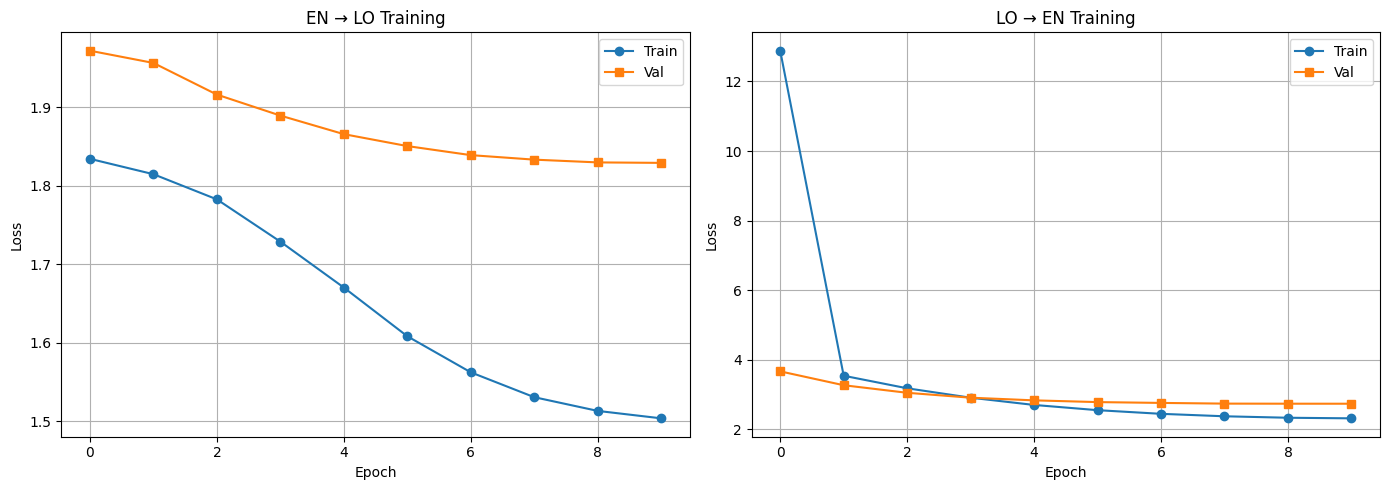

✅ Plot saved!


In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses,    label='Train', marker='o')
axes[0].plot(val_losses,      label='Val',   marker='s')
axes[0].set_title('EN → LO Training')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(lo_train_losses, label='Train', marker='o')
axes[1].plot(lo_val_losses,   label='Val',   marker='s')
axes[1].set_title('LO → EN Training')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('✅ Plot saved!')

In [29]:
print('=' * 60)
print('🏆 FINAL RESULTS')
print('=' * 60)
print(f'  Baseline BLEU (EN→LO) : {baseline_bleu}')
print(f'  Fine-tuned BLEU (EN→LO): {en_lo_bleu}')
print(f'  Fine-tuned BLEU (LO→EN): {lo_en_bleu}')
print()

test_sentences = [
    'Hello, how are you?',
    'I want to learn the Lao language.',
    'Thank you for your assistance.',
]
print('🔁 Round-trip test (EN → LO → EN):')
for sent in test_sentences:
    lo   = translate_en_to_lo_max(sent)
    back = translate_lo_to_en_max(lo)
    print(f'  Original : {sent}')
    print(f'  → Lao    : {lo}')
    print(f'  → Back   : {back}')
    print()

🏆 FINAL RESULTS
  Baseline BLEU (EN→LO) : BLEU = 13.45 32.8/16.0/10.1/6.2 (BP = 1.000 ratio = 1.396 hyp_len = 3075 ref_len = 2203)
  Fine-tuned BLEU (EN→LO): BLEU = 28.51 47.8/31.7/24.7/20.0 (BP = 0.969 ratio = 0.969 hyp_len = 5163 ref_len = 5326)
  Fine-tuned BLEU (LO→EN): BLEU = 29.81 55.0/36.9/28.7/23.3 (BP = 0.873 ratio = 0.881 hyp_len = 5882 ref_len = 6678)

🔁 Round-trip test (EN → LO → EN):
  Original : Hello, how are you?
  → Lao    : Halo, ທ່ານ ຢູ່ ແນວ ໃດ?
  → Back   : Hello, how are you?

  Original : I want to learn the Lao language.
  → Lao    : ຂ້າພະເຈົ້າຢາກຮຽນພາສາ Lao.
  → Back   : I want to learn the Lao language.

  Original : Thank you for your assistance.
  → Lao    : ຂອບ ໃຈ ສໍາ ລັບ ການ ຊ່ວຍ ເຫຼືອ ຂອງ ທ່ານ.
  → Back   : Thank you for your assistance.

